Chirag Bansal

Kernel     Accuracy   Precision  Recall     F1-Score
-------------------------------------------------------
linear     1.0000     1.0000     1.0000     1.0000
poly       1.0000     1.0000     1.0000     1.0000
rbf        1.0000     1.0000     1.0000     1.0000


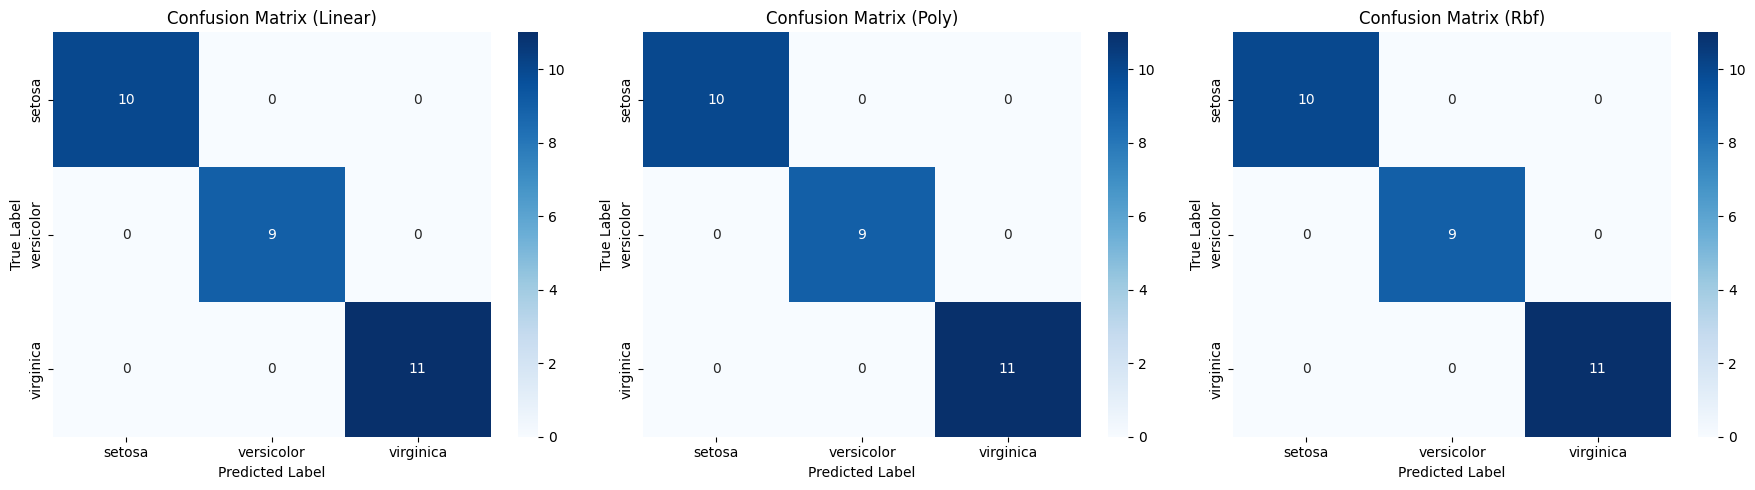


--- Analysis ---
1. Linear Kernel: Often performs perfectly on Iris because the classes (especially Setosa) are linearly separable.
2. RBF (Radial Basis Function): usually matches the Linear kernel on this simple dataset but is more powerful for complex overlaps.
3. Polynomial: May slightly overfit or underperform depending on the degree, but usually competitive.
Comparison: In this specific run (random_state=42), you will likely see all kernels performing very similarly (often 100% or near 100%), as the Iris dataset is small and clean.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# a) Load Data and Split
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 80:20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Kernels to evaluate
kernels = ['linear', 'poly', 'rbf']
results = {}

print(f"{'Kernel':<10} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score'}")
print("-" * 55)

plt.figure(figsize=(18, 5))

for i, kernel in enumerate(kernels):
    # b) Train Model
    # For poly, we specify degree=3 as requested
    if kernel == 'poly':
        model = SVC(kernel=kernel, degree=3, random_state=42)
    else:
        model = SVC(kernel=kernel, random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # c) Evaluate Metrics
    # Note: average='weighted' is used because Iris is a multiclass problem
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"{kernel:<10} {acc:.4f}     {prec:.4f}     {rec:.4f}     {f1:.4f}")

    # d) Display Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(1, 3, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix ({kernel.capitalize()})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# e) Analysis
print("\n--- Analysis ---")
print("1. Linear Kernel: Often performs perfectly on Iris because the classes (especially Setosa) are linearly separable.")
print("2. RBF (Radial Basis Function): usually matches the Linear kernel on this simple dataset but is more powerful for complex overlaps.")
print("3. Polynomial: May slightly overfit or underperform depending on the degree, but usually competitive.")
print("Comparison: In this specific run (random_state=42), you will likely see all kernels performing very similarly (often 100% or near 100%), as the Iris dataset is small and clean.")

In [8]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Dataset (Breast Cancer)
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Preprocessing (Standardization is crucial for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 3. Define the Model
knn = KNeighborsClassifier()

# 4. Define the Parameter Grid
# We will search for the best 'n_neighbors' (K) and 'weights' (uniform vs distance)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 5. Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1)

# 6. Perform the Search
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# 7. Results
print("\n--- Grid Search Results ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# 8. Evaluate best model on hold-out Test Set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print(f"Test Set Accuracy with Best Params: {test_accuracy:.4f}")

Starting Grid Search...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

--- Grid Search Results ---
Best Parameters Found: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Best Cross-Validation Score: 0.9623
Test Set Accuracy with Best Params: 0.9708
